# Chapter 9 — AutoML drought-impact prediction

Automated search over **models**, **predictor groups / subsets**, and **hyperparameters** for multi-label NUTS-3 impact occurrence.

- Panel: complete-case supervised frame 2018–2025
- Splits: **target-year** based (`year(t+h)`), so held-out periods are impact occurrence years
- Development targets: 2018–2023 (year expanding CV at $h=1$); independent test targets: 2024–2025
- Primary Optuna objective: macro Average Precision (AP) at $h=1$
- Final fit: shared Binary Relevance config evaluated at $h \in \{0,1,2,3\}$ with horizon-specific target-year masks


## 0. Setup

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from IPython.display import display
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

PACKAGE_ROOT = Path("..").resolve()
if not (PACKAGE_ROOT / "src" / "automl_search.py").exists():
    PACKAGE_ROOT = Path(".").resolve()
    if PACKAGE_ROOT.name == "notebooks":
        PACKAGE_ROOT = PACKAGE_ROOT.parent

sys.path.insert(0, str(PACKAGE_ROOT / "src"))

from automl_search import (
    DEV_TARGET_MAX_YEAR,
    FORECAST_HORIZONS,
    TOP_10_CLASSES,
    assert_target_year_splits,
    best_config_from_study,
    build_prediction_long,
    cv_score_config,
    evaluate_config_all_horizons,
    export_temporal_spatial_diagnostics,
    load_feature_groups,
    macro_from_class_metrics,
    make_optuna_objective,
    shap_mean_abs_importance,
    split_by_target_year,
    target_years,
    trials_dataframe,
    year_expanding_folds,
)

OUT_DIR = PACKAGE_ROOT / "data" / "processed"
RESULT_DIR = PACKAGE_ROOT / "results" / "automl_results"
FIG_DIR = RESULT_DIR / "figures"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_TRIALS = 100
RANDOM_SEED = 42
PRIMARY_HORIZON = 1
SHAP_N_MODELS_THRESHOLD = 0.05

print(f"Package: {PACKAGE_ROOT}")
print(f"Panels:  {OUT_DIR}")
print(f"Results: {RESULT_DIR}")


c:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Package: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting
Panels:  C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\data\processed
Results: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\results\automl_results


In [2]:
# Ensure Optuna is available
try:
    import optuna
except ImportError:
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "optuna"])
    import optuna

from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)
print("optuna", optuna.__version__)


optuna 4.9.0


In [3]:
import importlib

import automl_search

automl_search = importlib.reload(automl_search)
from automl_search import (
    DEV_TARGET_MAX_YEAR,
    FORECAST_HORIZONS,
    TOP_10_CLASSES,
    assert_target_year_splits,
    best_config_from_study,
    build_prediction_long,
    cv_score_config,
    evaluate_config_all_horizons,
    export_temporal_spatial_diagnostics,
    load_feature_groups,
    macro_from_class_metrics,
    make_optuna_objective,
    shap_mean_abs_importance,
    split_by_target_year,
    target_years,
    trials_dataframe,
    year_expanding_folds,
)

print("automl_search reloaded; target-year splits enabled")


automl_search reloaded; target-year splits enabled


## 1. Load prepared panel and feature groups

Uses the complete-case supervised panel and `feature_manifest.csv` group labels.
Train/validation/test masks are built from **year of target month** \(t+h\).


In [4]:
panel = pd.read_parquet(OUT_DIR / "supervised_nuts3_forecast_2018_2025_complete.parquet")
panel["year_month"] = pd.to_datetime(panel["year_month"])
if "year" not in panel.columns:
    panel["year"] = panel["year_month"].dt.year

feature_groups = load_feature_groups(OUT_DIR / "feature_manifest.csv")

assert_target_year_splits(panel, horizon=PRIMARY_HORIZON)
for h in FORECAST_HORIZONS:
    assert_target_year_splits(panel, horizon=h)

cv_mask = target_years(panel, PRIMARY_HORIZON) <= DEV_TARGET_MAX_YEAR
cv_panel = panel.loc[cv_mask].reset_index(drop=True)

print(
    f"Panel: {panel.shape}  |  "
    f"{panel['year_month'].min():%Y-%m} -> {panel['year_month'].max():%Y-%m}"
)
print(
    f"CV panel (target year <= {DEV_TARGET_MAX_YEAR}): {cv_panel.shape}  |  "
    f"split_rule=target_year(t+h), primary_h={PRIMARY_HORIZON}"
)
print(f"Feature groups: { {k: len(v) for k, v in feature_groups.items()} }")


Panel: (3714, 102)  |  2018-01 -> 2025-09
CV panel (target year <= 2023): (2837, 102)  |  split_rule=target_year(t+h), primary_h=1
Feature groups: {'class_lag': 10, 'meteo': 14, 'static_elev': 2, 'static_land': 3, 'static_pop': 1, 'static_soil': 18, 'temporal': 3}


## 2. Expanding-window temporal CV (thesis figure)

| Fold | Train years | Validation year |
|------|-------------|-----------------|
| 1 | 2018–2019 | 2020 |
| 2 | 2018–2020 | 2021 |
| 3 | 2018–2021 | 2022 |
| 4 | 2018–2022 | 2023 |


In [5]:
folds = year_expanding_folds(cv_panel, horizon=PRIMARY_HORIZON)
fold_summary = pd.DataFrame(
    [
        {
            "fold": f.fold,
            "train_years": "-".join(map(str, f.train_years)),
            "valid_year": f.valid_year,
            "n_train": len(f.train_idx),
            "n_valid": len(f.val_idx),
        }
        for f in folds
    ]
)
display(fold_summary)


,fold,train_years,valid_year,n_train,n_valid
0,1,2018-2019,2020,920,480
1,2,2018-2019-2020,2021,1400,477
2,3,2018-2019-2020-2021,2022,1877,480
3,4,2018-2019-2020-2021-2022,2023,2357,480


## 3. Optuna AutoML search

Search space:
- **Models:** Logistic Regression, Elastic Net, Random Forest, XGBoost, CatBoost
- **Predictor groups (all optional):** meteo, temporal, land, population, elevation, soil, class lags
- **Within-group subsets** when a group is on (e.g. SPI-only / SPEI-only / short–long scales; soil organic / sand–podzol / clay–loam; seasonal vs persistence temporal features). `year` is never a feature.
- **Hyperparameters:** wider model-conditional ranges
- **Objective:** mean fold **macro PR-AUC** at $h=1$


In [6]:
sampler = TPESampler(seed=RANDOM_SEED)
pruner = MedianPruner(n_startup_trials=8, n_warmup_steps=1)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
    study_name="ch9_drought_impact_automl",
)

objective = make_optuna_objective(
    cv_panel,
    feature_groups,
    folds,
    horizon=PRIMARY_HORIZON,
    classes=TOP_10_CLASSES,
)

print(f"Starting Optuna search: {N_TRIALS} trials (primary horizon h={PRIMARY_HORIZON})...")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest trial #{study.best_trial.number}: macro PR-AUC h=1 = {study.best_value:.4f}")
print(f"Best model: {study.best_trial.params['model']}")
print(f"n_features: {study.best_trial.user_attrs.get('n_features')}")
print(f"groups: {study.best_trial.user_attrs.get('feature_groups_used')}")
print(f"group_subsets: {study.best_trial.user_attrs.get('group_subsets')}")


Starting Optuna search: 100 trials (primary horizon h=1)...


Best trial: 95. Best value: 0.327982: 100%|██████████| 100/100 [10:21<00:00,  6.22s/it]


Best trial #95: macro PR-AUC h=1 = 0.3280
Best model: logistic_regression
n_features: 36
groups: ['meteo', 'temporal', 'static_pop', 'static_elev', 'static_soil']
group_subsets: {'meteo': 'all', 'temporal': 'seasonality', 'static_pop': 'all', 'static_elev': 'mean_only', 'static_soil': 'all'}


In [7]:
trials_df = trials_dataframe(study)
trials_df.to_csv(RESULT_DIR / "cv_trials.csv", index=False)
display(trials_df.head(15))

best = best_config_from_study(study)
best.save(RESULT_DIR / "best_config.json")
pd.DataFrame({"feature": best.features}).to_csv(RESULT_DIR / "selected_features.csv", index=False)

print("Saved best_config.json and selected_features.csv")
print(json.dumps({k: v for k, v in best.to_dict().items() if k != "features"}, indent=2))
print(f"\nSelected features ({len(best.features)}):")
print(best.features)


,trial,state,macro_pr_auc_h1,model,n_features,feature_groups,group_subsets,subset_meteo,subset_static_pop,subset_static_elev,...,param_class_lag_subset,param_max_depth,param_n_estimators,param_min_samples_leaf,param_iterations,param_depth,param_learning_rate,param_l2_leaf_reg,param_subsample,param_colsample_bytree
90,90,TrialState.PRUNED,0.402206,logistic_regression,17,"meteo,temporal,static_pop","{""meteo"": ""all"", ""static_pop"": ""all"", ""tempora...",all,all,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
63,63,TrialState.PRUNED,0.394907,xgboost,41,"meteo,temporal,static_elev,static_soil,class_lag","{""class_lag"": ""all"", ""meteo"": ""spei_only"", ""st...",spei_only,NaN,both,...,all,3.0,600.0,NaN,NaN,NaN,0.057895,NaN,0.683397,0.609821
54,54,TrialState.PRUNED,0.387509,xgboost,32,"meteo,temporal,static_elev,static_soil,class_lag","{""class_lag"": ""fire"", ""meteo"": ""spei_only"", ""s...",spei_only,NaN,both,...,fire,5.0,150.0,NaN,NaN,NaN,0.075305,NaN,0.995886,0.580336
55,55,TrialState.PRUNED,0.384871,xgboost,24,"meteo,temporal,static_elev,static_soil,class_lag","{""class_lag"": ""all"", ""meteo"": ""spei_only"", ""st...",spei_only,NaN,both,...,all,3.0,350.0,NaN,NaN,NaN,0.039022,NaN,0.590135,0.668078
80,80,TrialState.PRUNED,0.384391,logistic_regression,7,"meteo,static_pop,static_elev,static_soil","{""meteo"": ""aux_only"", ""static_elev"": ""mean_onl...",aux_only,all,mean_only,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,46,TrialState.PRUNED,0.383457,xgboost,22,"meteo,temporal,static_land,static_soil,class_lag","{""class_lag"": ""all"", ""meteo"": ""spei_only"", ""st...",spei_only,NaN,NaN,...,all,3.0,150.0,NaN,NaN,NaN,0.048549,NaN,0.554812,0.502490
50,50,TrialState.PRUNED,0.382749,xgboost,22,"meteo,temporal,static_elev,class_lag","{""class_lag"": ""all"", ""meteo"": ""long"", ""static_...",long,NaN,std_only,...,all,10.0,200.0,NaN,NaN,NaN,0.177628,NaN,0.632209,0.608662
47,47,TrialState.PRUNED,0.371807,logistic_regression,32,"temporal,static_pop,static_elev,static_soil,cl...","{""class_lag"": ""all"", ""static_elev"": ""std_only""...",NaN,all,std_only,...,all,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,36,TrialState.PRUNED,0.371466,catboost,13,"meteo,temporal,static_elev","{""meteo"": ""spi_only"", ""static_elev"": ""both"", ""...",spi_only,NaN,both,...,NaN,NaN,NaN,NaN,600.0,2.0,0.121949,1.109682,NaN,NaN
60,60,TrialState.PRUNED,0.370895,xgboost,22,"meteo,temporal,static_elev,class_lag","{""class_lag"": ""all"", ""meteo"": ""spei_only"", ""st...",spei_only,NaN,std_only,...,all,5.0,350.0,NaN,NaN,NaN,0.031163,NaN,0.610488,0.672477


Saved best_config.json and selected_features.csv
{
  "model_name": "logistic_regression",
  "params": {
    "C": 0.017116947266545952
  },
  "cv_macro_pr_auc": 0.3279821699368137,
  "trial_number": 95,
  "feature_groups_used": [
    "meteo",
    "temporal",
    "static_pop",
    "static_elev",
    "static_soil"
  ],
  "group_subsets": {
    "meteo": "all",
    "temporal": "seasonality",
    "static_pop": "all",
    "static_elev": "mean_only",
    "static_soil": "all"
  }
}

Selected features (36):
['spei_01', 'spei_03', 'spei_06', 'spei_09', 'spei_12', 'spei_24', 'spi_01', 'spi_03', 'spi_06', 'spi_09', 'spi_12', 'spi_24', 'soil_moisture_anom', 'cdd_days', 'month_sin', 'month_cos', 'population_fraction', 'elevation_mean', 'soil_brikgronden', 'soil_dikke_eerdgronden', 'soil_gedefinieerde_associaties', 'soil_kalkhoudende_zandgronden', 'soil_kalkloze_zandgronden', 'soil_kalksteen_verweringsgronden', 'soil_keileemgronden', 'soil_leemgronden', 'soil_moerige_gronden', 'soil_niet_gerijpte_mine

In [8]:
# CV fold scores for the winning configuration (transparency)
cv_best = cv_score_config(cv_panel, best, folds, horizon=PRIMARY_HORIZON)
cv_best.to_csv(RESULT_DIR / "best_config_cv_folds.csv", index=False)
display(cv_best)
print(
    f"Mean CV macro PR-AUC h=1: "
    f"{cv_best['macro_pr_auc'].mean():.4f} ± {cv_best['macro_pr_auc'].std():.4f}"
)

top_by_model = (
    trials_df.dropna(subset=["macro_pr_auc_h1"])
    .groupby("model", as_index=False)["macro_pr_auc_h1"]
    .max()
    .sort_values("macro_pr_auc_h1", ascending=False)
)
display(top_by_model)


,fold,train_years,valid_year,macro_pr_auc,horizon
0,1,2018-2019,2020,0.484311,1
1,2,2018-2019-2020,2021,0.157404,1
2,3,2018-2019-2020-2021,2022,0.363825,1
3,4,2018-2019-2020-2021-2022,2023,0.306389,1


Mean CV macro PR-AUC h=1: 0.3280 ± 0.1358


,model,macro_pr_auc_h1
2,logistic_regression,0.402206
4,xgboost,0.394907
0,catboost,0.371466
3,random_forest,0.363392
1,elastic_net,0.347343


## 4. Retrain with target-year development / test masks and evaluate all horizons

The selected configuration is retrained separately per horizon $h \in \{0,1,2,3\}$ on rows with impact year $(t+h) \le 2023$, then scored on impact years 2024–2025.


In [9]:
test_metrics, models_by_h, proba_by_h = evaluate_config_all_horizons(
    panel,
    best,
    horizons=FORECAST_HORIZONS,
    classes=TOP_10_CLASSES,
)
test_metrics.to_csv(RESULT_DIR / "test_metrics_by_class_horizon.csv", index=False)
macro_test = macro_from_class_metrics(test_metrics)
macro_test.to_csv(RESULT_DIR / "test_macro_by_horizon.csv", index=False)

display(macro_test.round(4))
display(
    test_metrics.loc[test_metrics["horizon"] == 1, ["class", "pr_auc", "roc_auc", "f1", "prevalence"]]
    .sort_values("pr_auc", ascending=False)
    .round(4)
)


,horizon,macro_pr_auc,macro_roc_auc,macro_precision,macro_recall,macro_f1,macro_brier,macro_prevalence
0,0,0.3241,0.7660,0.1678,0.7572,0.2685,0.2313,0.0931
1,1,0.2648,0.7415,0.1713,0.6691,0.2656,0.2030,0.0903
2,2,0.2430,0.7295,0.1560,0.6816,0.2476,0.2190,0.0902
3,3,0.2725,0.7409,0.1703,0.6552,0.2621,0.1974,0.0888


,class,pr_auc,roc_auc,f1,prevalence
10,Crop Failure & Yield Reduction,0.5293,0.8048,0.4332,0.1460
14,Water Use Restrictions,0.4511,0.8209,0.2264,0.0559
17,Irrigation Shortage,0.3110,0.7922,0.2940,0.0889
13,Groundwater Depletion,0.2853,0.7095,0.2736,0.1095
15,Forest Dieback & Vegetation Stress,0.2644,0.7219,0.3182,0.1072
11,Reservoir & Surface Water Shortage,0.2021,0.7521,0.3303,0.0992
18,Water Supply & Sanitation Issues,0.1939,0.6879,0.2630,0.1140
12,Freshwater Ecosystem Degradation,0.1766,0.6293,0.2451,0.1186
16,Agricultural Economic Loss,0.1727,0.7755,0.1429,0.0365
19,Wildfire Occurrence,0.0615,0.7208,0.1294,0.0274


,class,pr_auc,prevalence,pr_auc_skill
14,Water Use Restrictions,0.4511,0.0559,0.3952
10,Crop Failure & Yield Reduction,0.5293,0.1460,0.3834
17,Irrigation Shortage,0.3110,0.0889,0.2220
13,Groundwater Depletion,0.2853,0.1095,0.1758
15,Forest Dieback & Vegetation Stress,0.2644,0.1072,0.1573
16,Agricultural Economic Loss,0.1727,0.0365,0.1362
11,Reservoir & Surface Water Shortage,0.2021,0.0992,0.1028
18,Water Supply & Sanitation Issues,0.1939,0.1140,0.0799
12,Freshwater Ecosystem Degradation,0.1766,0.1186,0.0580
19,Wildfire Occurrence,0.0615,0.0274,0.0342


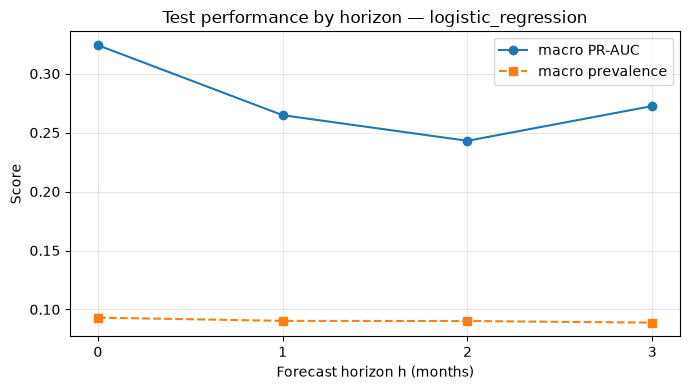

In [10]:
# Prevalence baseline skill: PR-AUC - prevalence
skill = test_metrics.copy()
skill["pr_auc_skill"] = skill["pr_auc"] - skill["prevalence"]
skill_h1 = skill.loc[
    skill["horizon"] == 1, ["class", "pr_auc", "prevalence", "pr_auc_skill"]
].sort_values("pr_auc_skill", ascending=False)
display(skill_h1.round(4))
skill.to_csv(RESULT_DIR / "test_metrics_with_skill.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(macro_test["horizon"], macro_test["macro_pr_auc"], marker="o", label="macro PR-AUC")
ax.plot(
    macro_test["horizon"],
    macro_test["macro_prevalence"],
    marker="s",
    linestyle="--",
    label="macro prevalence",
)
ax.set_xlabel("Forecast horizon h (months)")
ax.set_ylabel("Score")
ax.set_xticks(FORECAST_HORIZONS)
ax.set_title(f"Test performance by horizon — {best.model_name}")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_test_macro_by_horizon.png", dpi=150)
plt.show()


## 5. Post-hoc XAI (SHAP)

Mean absolute SHAP values aggregated across the ten Binary Relevance models at $h=1$.


Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.
Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP val

,feature,mean_abs_shap,n_models,n_models_evaluated
0,month_cos,0.6527,10,10
1,spei_09,0.4938,10,10
2,spei_06,0.4664,10,10
3,spi_12,0.4636,9,10
4,spi_09,0.2004,10,10
5,soil_moerige_gronden,0.1940,10,10
6,spi_03,0.1674,8,10
7,soil_podzolgronden,0.1562,9,10
8,spei_12,0.1461,8,10
9,cdd_days,0.1423,10,10


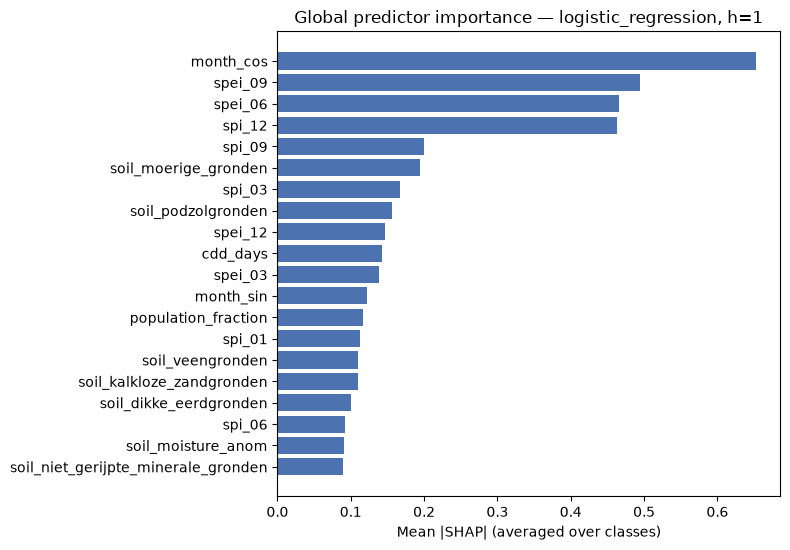

In [11]:
_, test_h1 = split_by_target_year(panel, horizon=PRIMARY_HORIZON)
models_h1 = models_by_h[PRIMARY_HORIZON]
shap_imp = shap_mean_abs_importance(
    models_h1,
    test_h1,
    best.features,
    model_name=best.model_name,
    max_samples=400,
    max_bg=200,
    shap_threshold=SHAP_N_MODELS_THRESHOLD,
)
shap_imp.to_csv(RESULT_DIR / "shap_importance_h1.csv", index=False)
display(shap_imp.head(15).round(4))

top_n = min(20, len(shap_imp))
plot_df = shap_imp.head(top_n).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.28)))
ax.barh(plot_df["feature"], plot_df["mean_abs_shap"], color="#4C72B0")
ax.set_xlabel("Mean |SHAP| (averaged over classes)")
ax.set_title(f"Global predictor importance — {best.model_name}, h={PRIMARY_HORIZON}")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_shap_importance_h1.png", dpi=150)
plt.show()


## 6. Error diagnostics (time & space)

Post-hoc diagnostics on **held-out test** predictions at $h=1$ (reuse `proba_by_h[1]`).

**Caveat:** the test window is short (~21 months), so year-level claims are weak. Calendar month, SPEI-12 drought bins, and JJA regional maps are the main signals for off-drought vs drought and summer spatial skill.

**Metric rules per slice:** always report $n$, positives, prevalence, mean predicted probability, and Brier. PR-AUC and skill ($\mathrm{PR\text{-}AUC}-\mathrm{prevalence}$) only if both classes appear and $\ge 5$ positives. Overall views macro-average PR-AUC/skill over classes with a valid PR-AUC in that slice.

**Drought bins (SPEI-12):** dry $\le -1$; near-normal $(-1,1)$; wet $\ge 1$. Expectation: worse skill / higher Brier off-drought.


### 6.1 Temporal performance

In [12]:
# Long prediction frame + full diagnostic export (CSVs + figures)
proba_h1 = proba_by_h[PRIMARY_HORIZON]
_, test_h1 = split_by_target_year(panel, horizon=PRIMARY_HORIZON)
diag_paths = export_temporal_spatial_diagnostics(
    test_h1,
    proba_h1,
    TOP_10_CLASSES,
    RESULT_DIR,
    horizon=PRIMARY_HORIZON,
    notebook_dir=PACKAGE_ROOT,
)
for k, p in diag_paths.items():
    print(f"{k}: {p}")
pred_long = build_prediction_long(test_h1, proba_h1, TOP_10_CLASSES, horizon=PRIMARY_HORIZON)
print(pred_long.head())


prediction_long: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\results\automl_results\diag_prediction_long_h1.csv
temporal_by_month: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\results\automl_results\diag_temporal_by_month.csv
fig_temporal_by_month: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\results\automl_results\figures\fig_diag_temporal_by_month.png
temporal_by_calendar_month: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\results\automl_results\diag_temporal_by_calendar_month.csv
fig_temporal_by_calendar_month: C:\Users\hoeven\Downloads\Thesis ha

By year-month (tail):


,year_month,n,n_pos,n_classes,n_classes_pr,macro_prevalence,macro_mean_pred,macro_brier,macro_pr_auc,macro_skill
14,2025-02-01,400.0,17.0,10.0,0.0,0.0425,0.3253,0.1526,NaN,NaN
15,2025-03-01,400.0,68.0,10.0,8.0,0.1700,0.5366,0.2827,0.4732,0.2638
16,2025-04-01,400.0,114.0,10.0,9.0,0.2850,0.5462,0.2836,0.5345,0.2234
17,2025-05-01,400.0,43.0,10.0,5.0,0.1075,0.6241,0.3698,0.5060,0.3260
18,2025-06-01,400.0,147.0,10.0,9.0,0.3675,0.6560,0.2965,0.6094,0.2066
19,2025-07-01,400.0,79.0,10.0,7.0,0.1975,0.6098,0.3252,0.5497,0.2961
20,2025-08-01,400.0,33.0,10.0,3.0,0.0825,0.6322,0.3935,0.5984,0.4067
21,2025-09-01,400.0,13.0,10.0,1.0,0.0325,0.3667,0.1778,0.1935,0.0185



By calendar month:


,month,n,n_pos,n_classes,n_classes_pr,macro_prevalence,macro_mean_pred,macro_brier,macro_pr_auc,macro_skill
0,1,800.0,15.0,10.0,0.0,0.0188,0.2432,0.0927,NaN,NaN
1,2,770.0,28.0,10.0,3.0,0.0364,0.2896,0.1299,0.1059,0.0410
2,3,800.0,95.0,10.0,9.0,0.1188,0.4108,0.2003,0.4193,0.2887
3,4,800.0,135.0,10.0,10.0,0.1688,0.4627,0.2353,0.4188,0.2500
4,5,800.0,66.0,10.0,6.0,0.0825,0.5706,0.3311,0.4059,0.2851
5,6,800.0,169.0,10.0,9.0,0.2112,0.6023,0.3057,0.5356,0.3037
6,7,800.0,106.0,10.0,8.0,0.1325,0.5385,0.2873,0.4199,0.2621
7,8,800.0,48.0,10.0,4.0,0.0600,0.5351,0.3116,0.3986,0.2955
8,9,800.0,38.0,10.0,4.0,0.0475,0.3511,0.1592,0.2838,0.1807
9,10,400.0,9.0,10.0,0.0,0.0225,0.2458,0.0933,NaN,NaN



By drought bin (SPEI-12):


,drought_bin,n,n_pos,n_classes,n_classes_pr,macro_prevalence,macro_mean_pred,macro_brier,macro_pr_auc,macro_skill
0,dry,1410.0,187.0,10.0,9.0,0.1326,0.5312,0.2840,0.3179,0.1737
1,near_normal,1650.0,290.0,10.0,10.0,0.1758,0.5258,0.2782,0.3769,0.2011
2,wet,5710.0,315.0,10.0,10.0,0.0552,0.3373,0.1613,0.1581,0.1029


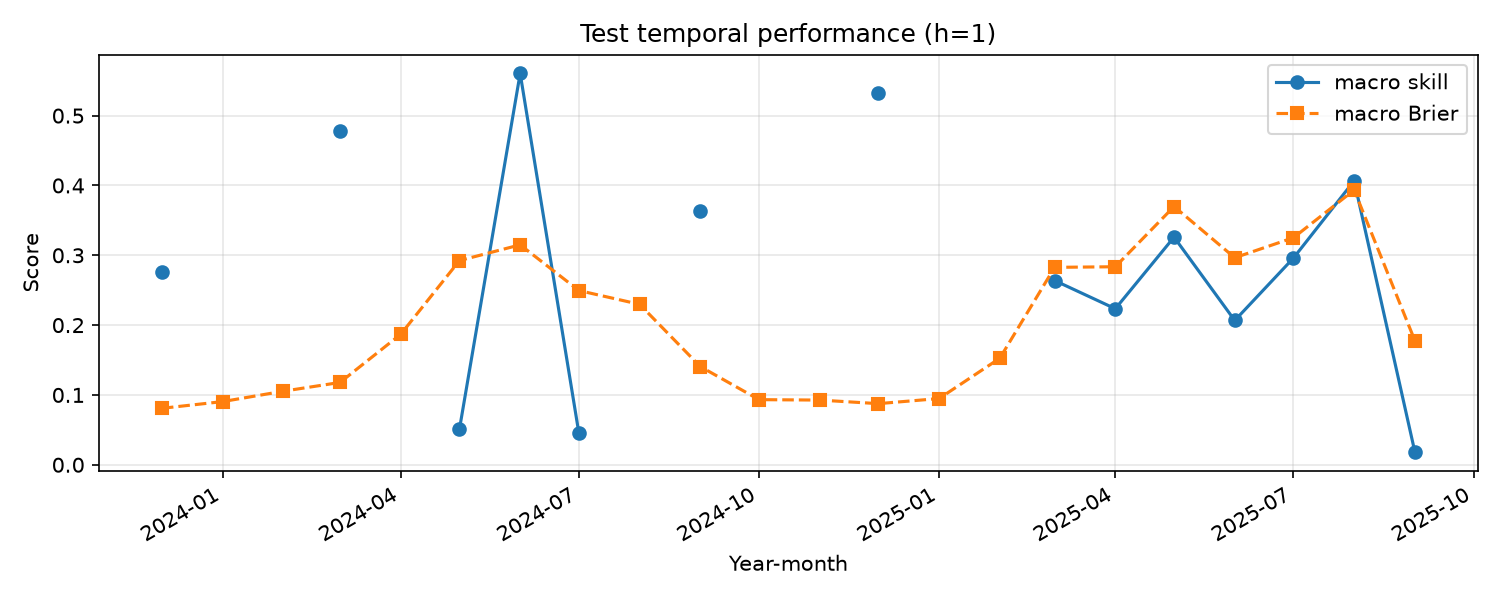

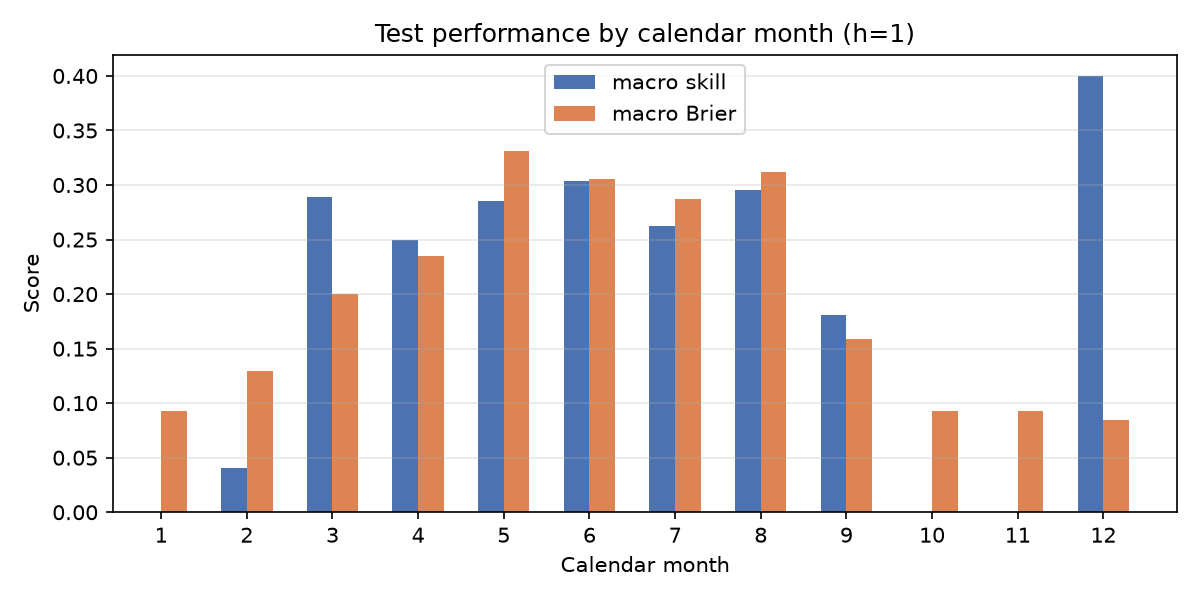

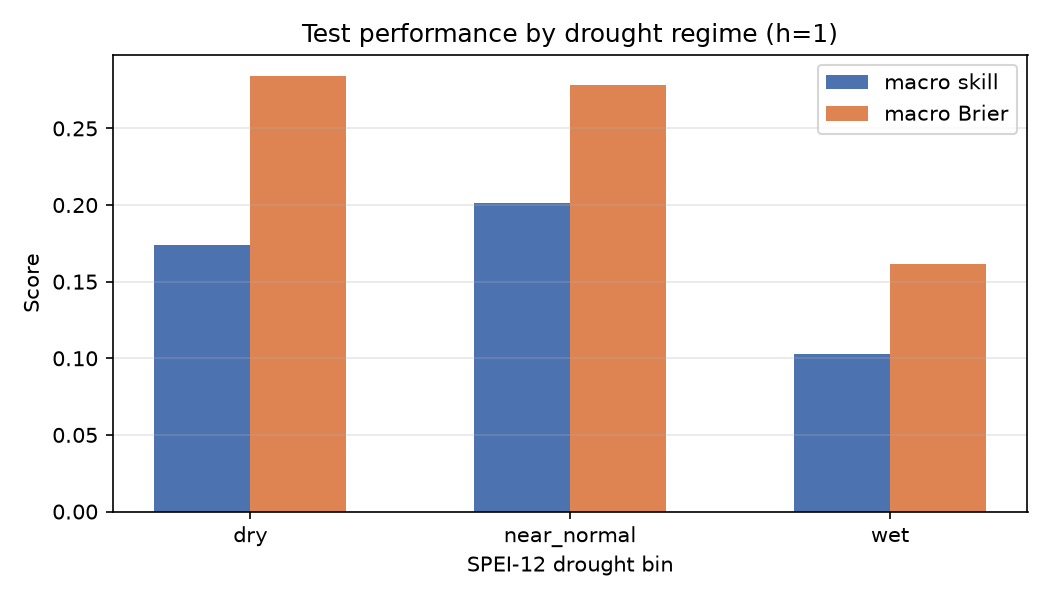

In [13]:
# Inspect temporal tables already exported by export_temporal_spatial_diagnostics
by_ym = pd.read_csv(RESULT_DIR / "diag_temporal_by_month.csv", parse_dates=["year_month"])
by_cal = pd.read_csv(RESULT_DIR / "diag_temporal_by_calendar_month.csv")
by_dry = pd.read_csv(RESULT_DIR / "diag_temporal_by_drought_bin.csv")

print("By year-month (tail):")
display(by_ym.tail(8).round(4))
print("\nBy calendar month:")
display(by_cal.round(4))
print("\nBy drought bin (SPEI-12):")
display(by_dry.round(4))

# Show the figures written to disk
from IPython.display import Image, display as idisplay

for name in [
    "fig_diag_temporal_by_month.png",
    "fig_diag_temporal_by_calendar_month.png",
    "fig_diag_temporal_by_drought_bin.png",
]:
    idisplay(Image(filename=str(FIG_DIR / name)))


### 6.2 Regional performance

Per NUTS-3 macro skill on the full test period (choropleth + ranked table). Regions without enough positives for PR-AUC still contribute Brier; ranking falls back to lower Brier when skill is missing.


Best regions (by skill / Brier fallback):


,nuts3_id,nuts3_name,macro_skill,macro_pr_auc,macro_brier,n_pos,n_classes_pr
0,NL33C,Groot-Rijnmond,0.5827,0.8100,0.2764,18.0,1.0
1,NL423,Zuid-Limburg,0.4203,0.6476,0.2283,21.0,1.0
2,NL329,Groot-Amsterdam,0.3976,0.6476,0.1741,33.0,4.0
3,NL414,Zuidoost-Noord-Brabant,0.3104,0.6195,0.3309,46.0,5.0
4,NL225,Achterhoek,0.3022,0.5522,0.3210,30.0,2.0
5,NL412,Midden-Noord-Brabant,0.2654,0.5608,0.2897,37.0,4.0
6,NL341,Zeeuwsch-Vlaanderen,0.2542,0.6292,0.2225,41.0,4.0
7,NL342,Overig Zeeland,0.2420,0.6966,0.1955,49.0,4.0



Worst regions:


,nuts3_id,nuts3_name,macro_skill,macro_pr_auc,macro_brier,n_pos,n_classes_pr
32,NL327,Het Gooi en Vechtstreek,NaN,NaN,0.1793,9.0,0.0
33,NL321,Kop van Noord-Holland,NaN,NaN,0.1802,21.0,0.0
34,NL230,Flevoland,NaN,NaN,0.1803,12.0,0.0
35,NL124,Noord-Friesland,NaN,NaN,0.1914,20.0,0.0
36,NL224,Zuidwest-Gelderland,NaN,NaN,0.1937,12.0,0.0
37,NL226,Arnhem/Nijmegen,NaN,NaN,0.2582,19.0,0.0
38,NL421,Noord-Limburg,NaN,NaN,0.2856,19.0,0.0
39,NL212,Zuidwest-Overijssel,NaN,NaN,0.2987,12.0,0.0


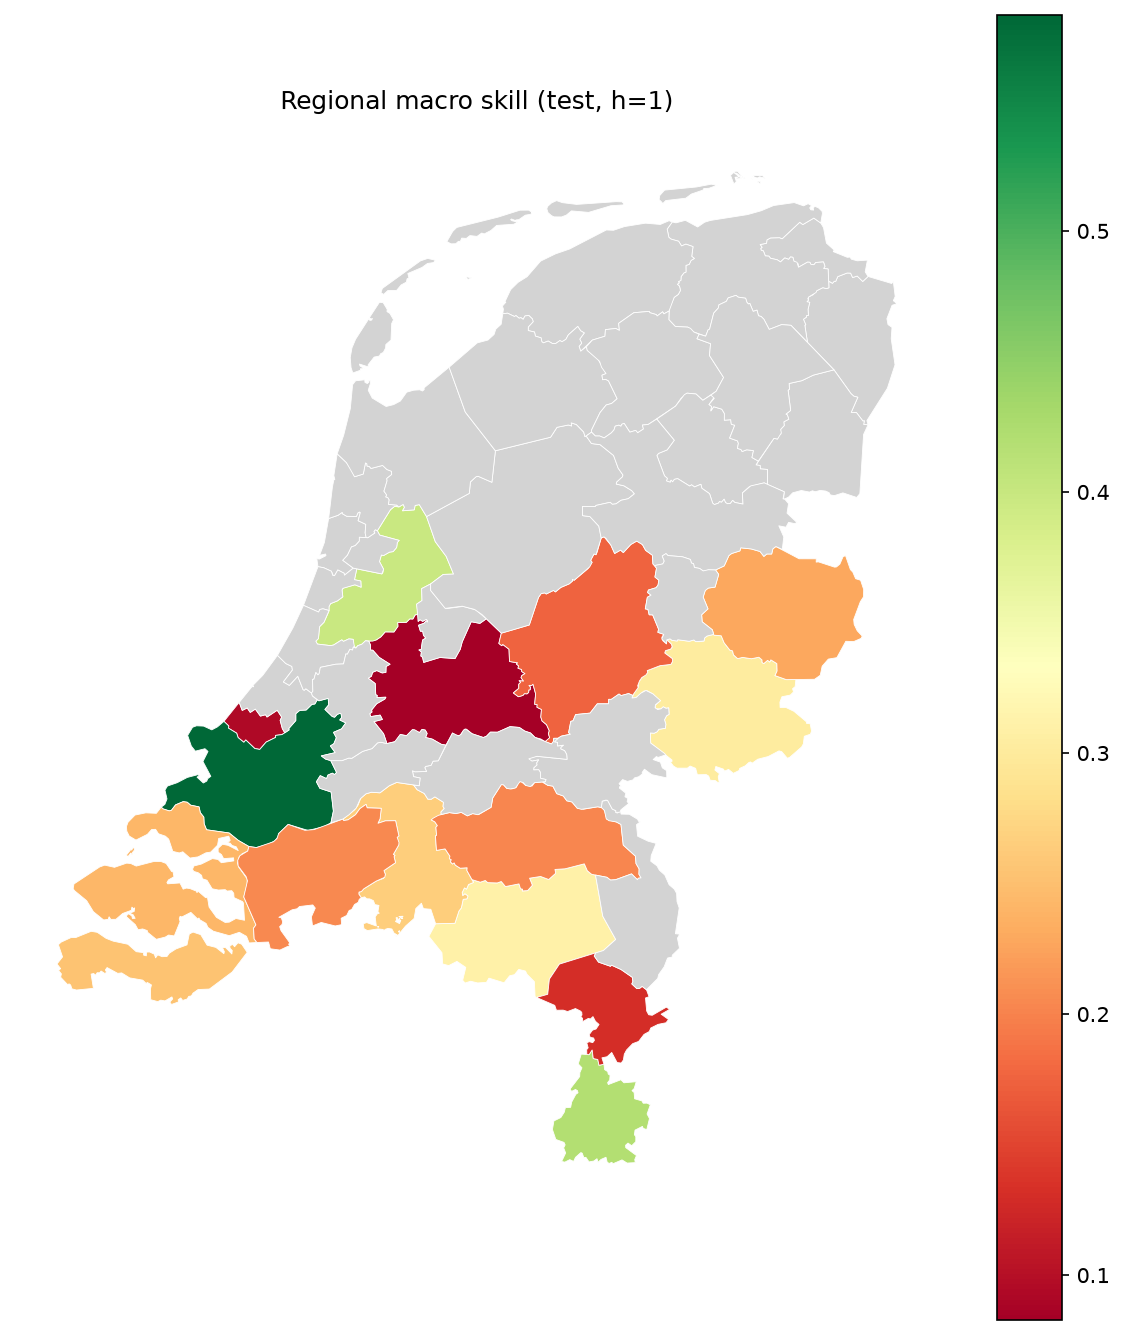

In [14]:
by_nuts = pd.read_csv(RESULT_DIR / "diag_spatial_by_nuts3.csv")
print("Best regions (by skill / Brier fallback):")
display(by_nuts.head(8)[["nuts3_id", "nuts3_name", "macro_skill", "macro_pr_auc", "macro_brier", "n_pos", "n_classes_pr"]].round(4))
print("\nWorst regions:")
display(by_nuts.tail(8)[["nuts3_id", "nuts3_name", "macro_skill", "macro_pr_auc", "macro_brier", "n_pos", "n_classes_pr"]].round(4))

from IPython.display import Image, display as idisplay

choropleth = FIG_DIR / "fig_spatial_skill_choropleth.png"
if choropleth.exists():
    idisplay(Image(filename=str(choropleth)))
else:
    print("Choropleth figure missing — check geopandas / NUTS geojson path.")


### 6.3 Dependence on impact class

Do temporal and spatial patterns differ by impact type? Heatmaps for class × calendar month and class × drought bin; top/bottom NUTS-3 per class.


Class × drought bin (skill):


drought_bin,dry,near_normal,wet
class,,,
Agricultural Economic Loss,0.1629,0.2760,0.0221
Crop Failure & Yield Reduction,0.3519,0.4108,0.0945
Forest Dieback & Vegetation Stress,0.0645,0.0829,0.2690
Freshwater Ecosystem Degradation,0.2888,0.0625,0.0155
Groundwater Depletion,0.3041,0.1850,0.1168
Irrigation Shortage,0.1550,0.2386,0.2020
Reservoir & Surface Water Shortage,0.0416,0.0201,0.0156
Water Supply & Sanitation Issues,0.1466,0.1627,0.0575
Water Use Restrictions,0.0476,0.5421,0.1974



Top/bottom regions per class (sample):


,class,kind,nuts3_id,nuts3_name,skill,brier,pr_auc,n_pos
0,Agricultural Economic Loss,best,NL342,Overig Zeeland,0.3234,0.2362,0.7325,9.0
1,Agricultural Economic Loss,best,NL341,Zeeuwsch-Vlaanderen,0.2072,0.2805,0.5254,7.0
2,Agricultural Economic Loss,best,NL33B,Oost-Zuid-Holland,NaN,0.0561,NaN,0.0
3,Agricultural Economic Loss,worst,NL225,Achterhoek,NaN,0.3429,NaN,3.0
4,Agricultural Economic Loss,worst,NL221,Veluwe,NaN,0.3211,NaN,1.0
5,Agricultural Economic Loss,worst,NL33C,Groot-Rijnmond,NaN,0.3065,NaN,1.0
6,Crop Failure & Yield Reduction,best,NL329,Groot-Amsterdam,0.6328,0.1217,0.9056,6.0
7,Crop Failure & Yield Reduction,best,NL412,Midden-Noord-Brabant,0.5884,0.2023,0.8611,6.0
8,Crop Failure & Yield Reduction,best,NL33C,Groot-Rijnmond,0.5827,0.2703,0.8100,5.0
9,Crop Failure & Yield Reduction,worst,NL221,Veluwe,NaN,0.3390,NaN,3.0


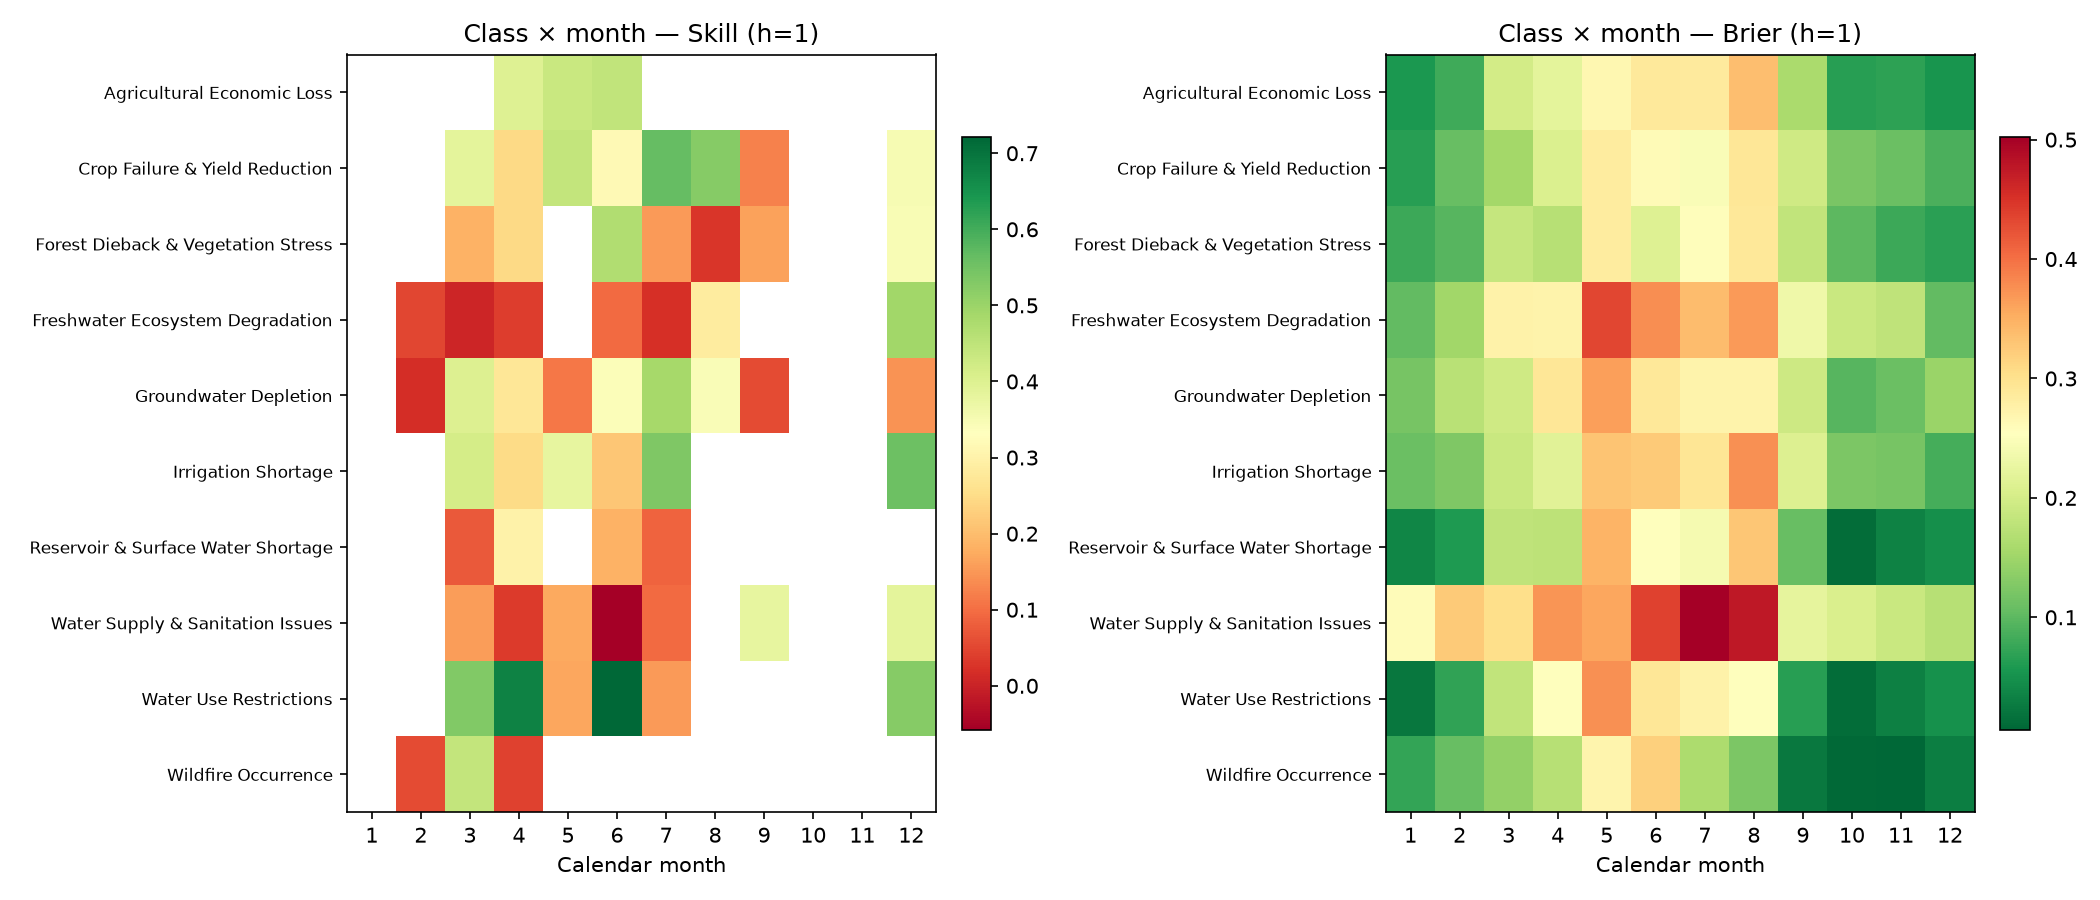

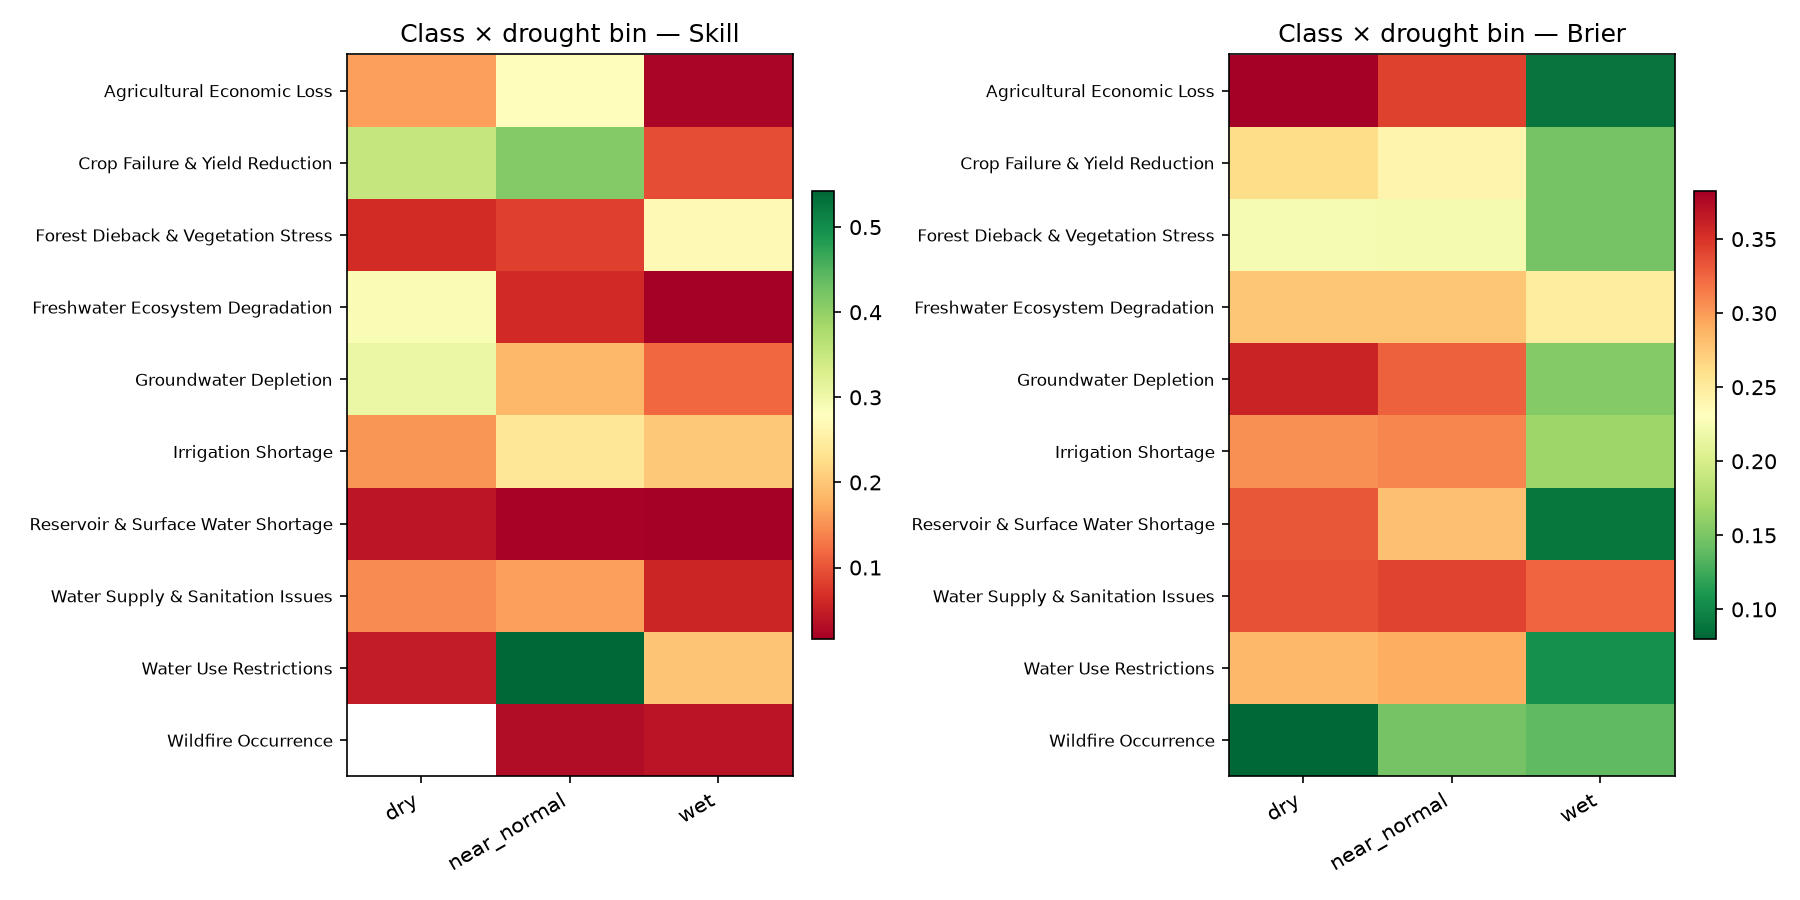

In [15]:
class_cal = pd.read_csv(RESULT_DIR / "diag_class_by_calendar_month.csv")
class_dry = pd.read_csv(RESULT_DIR / "diag_class_by_drought_bin.csv")
top_bottom = pd.read_csv(RESULT_DIR / "diag_class_nuts3_top_bottom.csv")

print("Class × drought bin (skill):")
display(
    class_dry.pivot(index="class", columns="drought_bin", values="skill")
    .reindex(columns=["dry", "near_normal", "wet"])
    .round(4)
)

print("\nTop/bottom regions per class (sample):")
display(top_bottom.head(24).round(4))

from IPython.display import Image, display as idisplay

for name in [
    "fig_diag_class_by_calendar_month.png",
    "fig_diag_class_by_drought_bin.png",
]:
    idisplay(Image(filename=str(FIG_DIR / name)))


### 6.4 Regional performance in JJA (Jun / Jul / Aug)

Restrict the test set to summer months and recompute per-NUTS-3 metrics. Compare ranks vs the all-months regional table.


Best JJA regions:


,nuts3_id,nuts3_name,macro_skill,macro_pr_auc,macro_brier,n_pos
0,NL325,Zaanstreek,NaN,NaN,0.1550,7.0
1,NL33B,Oost-Zuid-Holland,NaN,NaN,0.1592,4.0
2,NL125,Zuidwest-Friesland,NaN,NaN,0.1595,4.0
3,NL132,Zuidoost-Drenthe,NaN,NaN,0.1599,1.0
4,NL323,IJmond,NaN,NaN,0.1655,6.0
5,NL332,Agglomeratie ’s-Gravenhage,NaN,NaN,0.1821,5.0
6,NL324,Agglomeratie Haarlem,NaN,NaN,0.1969,7.0
7,NL126,Zuidoost-Friesland,NaN,NaN,0.2136,1.0



Worst JJA regions:


,nuts3_id,nuts3_name,macro_skill,macro_pr_auc,macro_brier,n_pos
32,NL414,Zuidoost-Noord-Brabant,NaN,NaN,0.4159,19.0
33,NL413,Noordoost-Noord-Brabant,NaN,NaN,0.4189,15.0
34,NL212,Zuidwest-Overijssel,NaN,NaN,0.4242,7.0
35,NL33C,Groot-Rijnmond,NaN,NaN,0.4254,5.0
36,NL422,Midden-Limburg,NaN,NaN,0.4264,9.0
37,NL213,Twente,NaN,NaN,0.4470,12.0
38,NL225,Achterhoek,NaN,NaN,0.4774,8.0
39,NL221,Veluwe,NaN,NaN,0.5104,8.0



Largest skill drops in JJA vs all months:


,nuts3_id,nuts3_name,skill_all,skill_jja,delta_skill_jja_minus_all,brier_all,brier_jja
0,NL111,Oost-Groningen,NaN,NaN,NaN,0.1385,0.2320
1,NL112,Delfzijl en omgeving,NaN,NaN,NaN,0.1748,0.2839
2,NL113,Overig Groningen,NaN,NaN,NaN,0.1439,0.2583
3,NL124,Noord-Friesland,NaN,NaN,NaN,0.1914,0.3036
4,NL125,Zuidwest-Friesland,NaN,NaN,NaN,0.1069,0.1595
5,NL126,Zuidoost-Friesland,NaN,NaN,NaN,0.1311,0.2136
6,NL131,Noord-Drenthe,NaN,NaN,NaN,0.1761,0.3084
7,NL132,Zuidoost-Drenthe,NaN,NaN,NaN,0.0850,0.1599
8,NL133,Zuidwest-Drenthe,NaN,NaN,NaN,0.1316,0.2359
9,NL211,Noord-Overijssel,NaN,NaN,NaN,0.1551,0.2490


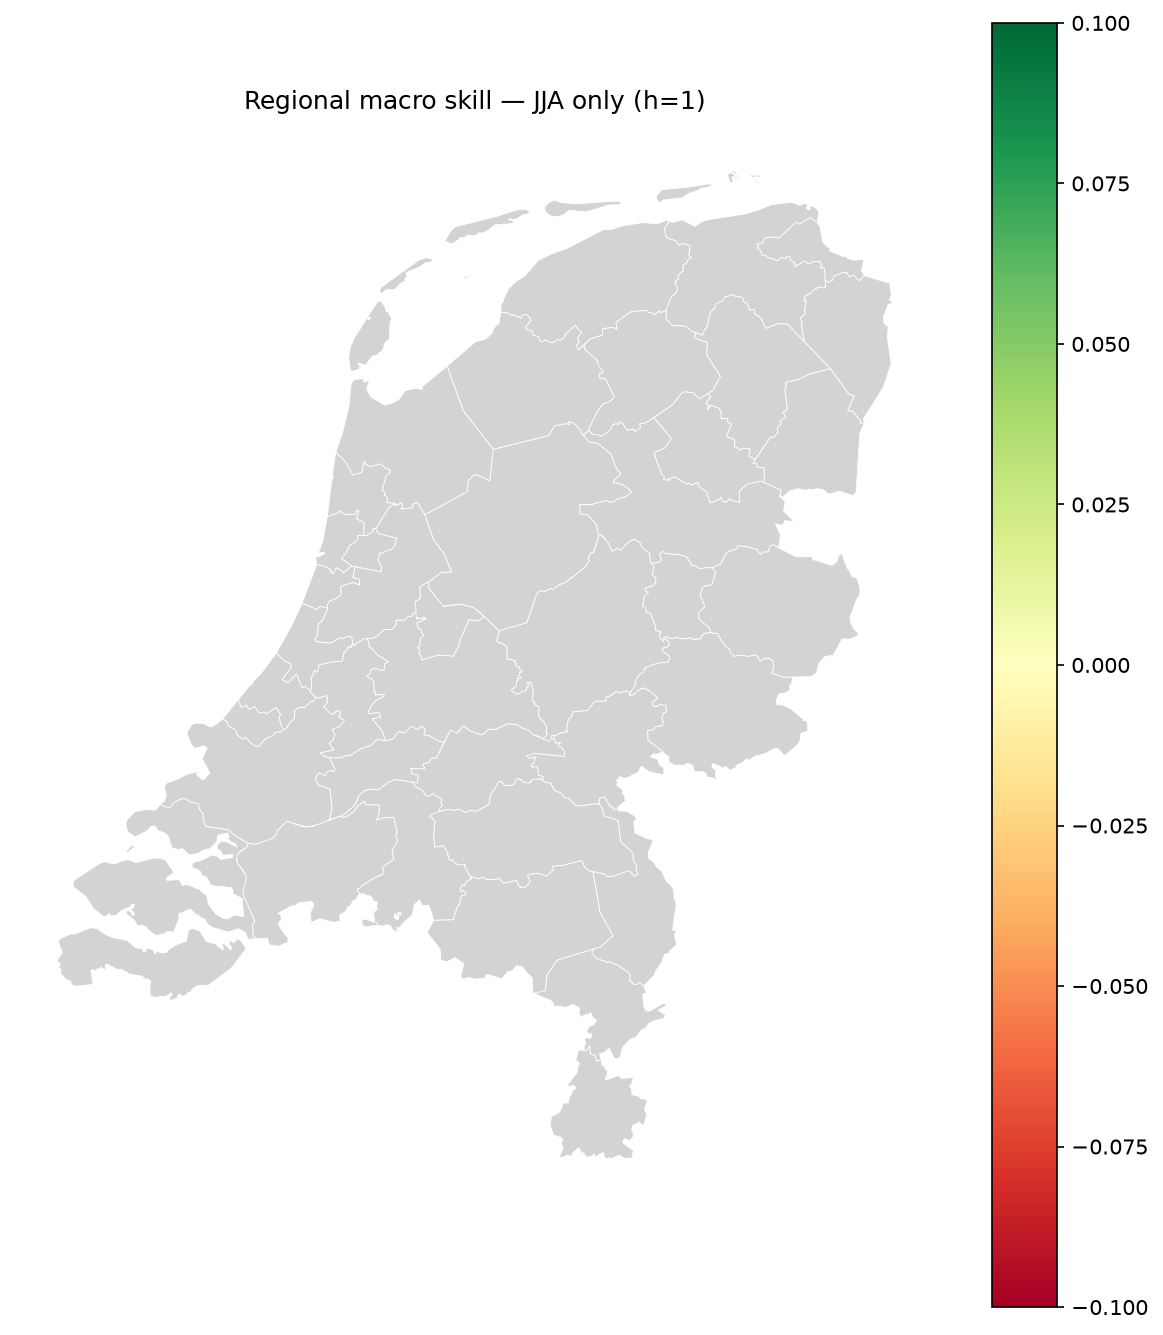

In [16]:
jja = pd.read_csv(RESULT_DIR / "diag_spatial_jja_by_nuts3.csv")
cmp = pd.read_csv(RESULT_DIR / "diag_spatial_all_vs_jja.csv")

print("Best JJA regions:")
display(jja.head(8)[["nuts3_id", "nuts3_name", "macro_skill", "macro_pr_auc", "macro_brier", "n_pos"]].round(4))
print("\nWorst JJA regions:")
display(jja.tail(8)[["nuts3_id", "nuts3_name", "macro_skill", "macro_pr_auc", "macro_brier", "n_pos"]].round(4))

print("\nLargest skill drops in JJA vs all months:")
display(
    cmp.assign(abs_delta=lambda d: d["delta_skill_jja_minus_all"].abs())
    .sort_values("delta_skill_jja_minus_all")
    .head(10)[
        ["nuts3_id", "nuts3_name", "skill_all", "skill_jja", "delta_skill_jja_minus_all", "brier_all", "brier_jja"]
    ]
    .round(4)
)

from IPython.display import Image, display as idisplay

jja_map = FIG_DIR / "fig_spatial_skill_choropleth_jja.png"
if jja_map.exists():
    idisplay(Image(filename=str(jja_map)))
else:
    print("JJA choropleth missing.")


## 7. Summary


In [17]:
summary = {
    "best_model": best.model_name,
    "cv_macro_pr_auc_h1": best.cv_macro_pr_auc,
    "n_features": len(best.features),
    "feature_groups": best.feature_groups_used,
    "group_subsets": best.group_subsets,
    "n_trials": N_TRIALS,
    "test_macro_pr_auc_by_horizon": {
        int(r.horizon): float(r.macro_pr_auc) for r in macro_test.itertuples()
    },
}
print(json.dumps(summary, indent=2))
(RESULT_DIR / "run_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

print("\nExports written to:", RESULT_DIR)
for p in sorted(RESULT_DIR.rglob("*")):
    if p.is_file():
        print(" -", p.relative_to(RESULT_DIR))


{
  "best_model": "logistic_regression",
  "cv_macro_pr_auc_h1": 0.3279821699368137,
  "n_features": 36,
  "feature_groups": [
    "meteo",
    "temporal",
    "static_pop",
    "static_elev",
    "static_soil"
  ],
  "group_subsets": {
    "meteo": "all",
    "temporal": "seasonality",
    "static_pop": "all",
    "static_elev": "mean_only",
    "static_soil": "all"
  },
  "n_trials": 100,
  "test_macro_pr_auc_by_horizon": {
    "0": 0.324142770629219,
    "1": 0.2647828984160758,
    "2": 0.24304943728251435,
    "3": 0.2725266255114584
  }
}

Exports written to: C:\Users\hoeven\Downloads\Thesis hand-in\Impact-Based-Drought-Forecasting-in-the-Netherlands-Using-LLM-Extracted-News-Data\chapters\09_baseline_forecasting\results\automl_results
 - best_config.json
 - best_config_cv_folds.csv
 - cv_trials.csv
 - diag_class_by_calendar_month.csv
 - diag_class_by_drought_bin.csv
 - diag_class_by_nuts3.csv
 - diag_class_nuts3_top_bottom.csv
 - diag_prediction_long_h1.csv
 - diag_spatial_all_vs